# **Importings**

In [2]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import time
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
import pickle

# **Data Loading**

In [4]:
df_train = pd.read_csv(r'C:\Users\dell\Desktop\Guest_Satisfaction_Prediction\Milestone2\df_train.csv')
df_test = pd.read_csv(r'C:\Users\dell\Desktop\Guest_Satisfaction_Prediction\Milestone2\df_test.csv')
X_train = df_train.drop(columns=['guest_satisfaction'])
Y_train = df_train['guest_satisfaction']
X_test = df_test.drop(columns=['guest_satisfaction'])
Y_test = df_test['guest_satisfaction']

In [6]:
y_encoder_path = r"C:\Users\dell\Desktop\Guest_Satisfaction_Prediction\Milestone2\y_label_encoder.pkl"
with open(y_encoder_path, "rb") as f:
        y_encoder = pickle.load(f)

# **Models**

In [7]:
numeric_features = [
    'host_response_rate', 'host_is_superhost', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'nightly_price',
    'cleaning_fee', 'number_of_reviews', 'minimum_nights',
    'host_listings_count', 'number_of_stays', 'security_deposit',
    'extra_people', 'maximum_nights', 'guests_included'
]

categorical_features = [
    'neighbourhood_cleansed', 'instant_bookable',
    'cancellation_policy', 'property_type', 'room_type'
]

amenity_features = [
    'has_wifi', 'has_air_conditioning', 'has_kitchen',
    'has_heating', 'has_tv', 'has_free_parking_on_premises',
    'has_iron', 'has_laptop_friendly_workspace'
]

In [8]:
# Verify features exist in X_train
missing_features = []
for feature in numeric_features + categorical_features + amenity_features:
    if feature not in X_train.columns:
        missing_features.append(feature)

if missing_features:
    print(f"Warning: These features are missing from your DataFrame and will be skipped: {missing_features}")
    numeric_features = [f for f in numeric_features if f in X_train.columns]
    categorical_features = [f for f in categorical_features if f in X_train.columns]
    amenity_features = [f for f in amenity_features if f in X_train.columns]

In [9]:
# Preprocessor with Imputer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('amenities', 'passthrough', amenity_features)
    ])


In [ ]:
# Define models with hyperparameter grids
models = {
    "Random Forest": {
        "model": RandomForestClassifier,
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "base_params": {"random_state": 42}
    },
    "XGBoost": {
        "model": XGBClassifier,
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 6, 9],
            "learning_rate": [0.01, 0.1, 0.3]
        },
        "base_params": {"random_state": 42, "eval_metric": "mlogloss"}
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier,
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.3]
        },
        "base_params": {"random_state": 42}
    },
    "Logistic Regression": {
        "model": LogisticRegression,
        "params": {
            "C": [0.1, 1.0, 10.0],
            "max_iter": [100, 200, 300],
            "solver": ["lbfgs", "liblinear", "saga"]
        },
        "base_params": {"random_state": 42, "multi_class": "multinomial"}
    },
    "SVM": {
        "model": SVC,
        "params": {
            "C": [0.1, 1.0, 10.0],
            "kernel": ["linear", "rbf", "poly"],
            "gamma": ["scale", "auto", 0.1]
        },
        "base_params": {"random_state": 42, "probability": True}
    },
    "KNN": {
        "model": KNeighborsClassifier,
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"],
            "p": [1, 2, 3]
        },
        "base_params": {}
    }
}

results = {}
training_times = {}
test_times = {}
best_params = {}

In [11]:
for name, model_info in models.items():
    print(f"\nTraining {name}...")
    model_class = model_info["model"]
    param_grid = model_info["params"]
    base_params = model_info["base_params"]

    best_accuracy = 0
    best_model = None
    best_param_set = {}

    # Iterate over each hyperparameter
    for param_name, param_values in param_grid.items():
        for value in param_values:
            # Fix other hyperparameters to default values
            current_params = base_params.copy()
            current_params[param_name] = value

            try:
                # Initialize model with current parameters
                model = model_class(**current_params)

                # Create pipeline
                pipeline = Pipeline([
                    ('preprocessor', preprocessor),
                    ('classifier', model)
                ])

                # Time training
                start_train = time.time()
                pipeline.fit(X_train, Y_train)
                training_time = time.time() - start_train

                # Compute training accuracy
                y_train_pred_encoded = pipeline.predict(X_train)
                y_train_pred_labels = y_encoder.inverse_transform(y_train_pred_encoded)
                y_train_labels = y_encoder.inverse_transform(Y_train)
                train_acc = accuracy_score(y_train_labels, y_train_pred_labels)

                # Compute cross-validation accuracy (5-fold)
                cv_scores = cross_val_score(pipeline, X_train, Y_train, cv=5, scoring='accuracy')
                cv_acc = np.mean(cv_scores)

                # Time testing
                start_test = time.time()
                y_pred_encoded = pipeline.predict(X_test)
                test_time = time.time() - start_test

                # Decode test predictions
                y_pred_labels = y_encoder.inverse_transform(y_pred_encoded)
                y_test_labels = y_encoder.inverse_transform(Y_test)

                # Calculate test accuracy
                test_acc = accuracy_score(y_test_labels, y_pred_labels)

                # Store results if best for this model (based on test accuracy)
                if test_acc > best_accuracy:
                    best_accuracy = test_acc
                    best_model = pipeline
                    best_param_set = current_params

                # Store results
                results.setdefault(name, []).append({
                    'params': {param_name: value},
                    'train_accuracy': train_acc,
                    'cv_accuracy': cv_acc,
                    'test_accuracy': test_acc,
                    'training_time': training_time,
                    'test_time': test_time,
                    'classification_report': classification_report(
                        y_test_labels, y_pred_labels,
                        target_names=['average', 'high', 'very high']
                    )
                })

                print(f"{name} with {param_name}={value}:")
                print(f"  Training Accuracy: {train_acc:.4f}")
                print(f"  Cross-Validation Accuracy: {cv_acc:.4f}")
                print(f"  Test Accuracy: {test_acc:.4f}")
                print(f"  Training Time: {training_time:.2f}s")
                print(f"  Test Time: {test_time:.2f}s")
                print("-" * 60)

            except Exception as e:
                print(f"Error with {name} ({param_name}={value}): {str(e)}")
                continue

    # Store best parameters and times
    if best_model is not None:
        best_params[name] = best_param_set
        training_times[name] = min([r['training_time'] for r in results[name]])
        test_times[name] = min([r['test_time'] for r in results[name]])



Training Random Forest...
Random Forest with n_estimators=100:
  Training Accuracy: 0.9990
  Cross-Validation Accuracy: 0.5922
  Test Accuracy: 0.6115
  Training Time: 6.73s
  Test Time: 0.07s
------------------------------------------------------------
Random Forest with n_estimators=200:
  Training Accuracy: 0.9990
  Cross-Validation Accuracy: 0.5936
  Test Accuracy: 0.6120
  Training Time: 12.55s
  Test Time: 0.12s
------------------------------------------------------------
Random Forest with n_estimators=300:
  Training Accuracy: 0.9990
  Cross-Validation Accuracy: 0.5958
  Test Accuracy: 0.6080
  Training Time: 21.74s
  Test Time: 0.18s
------------------------------------------------------------
Random Forest with max_depth=10:
  Training Accuracy: 0.6752
  Cross-Validation Accuracy: 0.5925
  Test Accuracy: 0.6034
  Training Time: 2.19s
  Test Time: 0.07s
------------------------------------------------------------
Random Forest with max_depth=20:
  Training Accuracy: 0.9943
  

c:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Gradient Boosting with learning_rate=0.01:
  Training Accuracy: 0.5945
  Cross-Validation Accuracy: 0.5812
  Test Accuracy: 0.5954
  Training Time: 6.16s
  Test Time: 0.02s
------------------------------------------------------------
Gradient Boosting with learning_rate=0.1:
  Training Accuracy: 0.6474
  Cross-Validation Accuracy: 0.5985
  Test Accuracy: 0.6080
  Training Time: 6.11s
  Test Time: 0.03s
------------------------------------------------------------
Gradient Boosting with learning_rate=0.3:
  Training Accuracy: 0.7114
  Cross-Validation Accuracy: 0.5829
  Test Accuracy: 0.6103
  Training Time: 5.93s
  Test Time: 0.03s
------------------------------------------------------------

Training Logistic Regression...


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.

Logistic Regression with C=0.1:
  Training Accuracy: 0.5872
  Cross-Validation Accuracy: 0.5743
  Test Accuracy: 0.5782
  Training Time: 1.45s
  Test Time: 0.02s
------------------------------------------------------------


...

Logistic Regression with max_iter=300:
  Training Accuracy: 0.5926
  Cross-Validation Accuracy: 0.5719
  Test Accuracy: 0.5782
  Training Time: 0.52s
  Test Time: 0.02s
------------------------------------------------------------


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always us

Logistic Regression with solver=lbfgs:
  Training Accuracy: 0.5934
  Cross-Validation Accuracy: 0.5727
  Test Accuracy: 0.5765
  Training Time: 0.25s
  Test Time: 0.02s
------------------------------------------------------------
Error with Logistic Regression (solver=liblinear): Solver liblinear does not support a multinomial backend.


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:3

Logistic Regression with solver=saga:
  Training Accuracy: 0.5925
  Cross-Validation Accuracy: 0.5727
  Test Accuracy: 0.5771
  Training Time: 0.57s
  Test Time: 0.01s
------------------------------------------------------------

Training SVM...
SVM with C=0.1:
  Training Accuracy: 0.5853
  Cross-Validation Accuracy: 0.5777
  Test Accuracy: 0.5673
  Training Time: 25.01s
  Test Time: 0.98s
------------------------------------------------------------
SVM with C=1.0:
  Training Accuracy: 0.6275
  Cross-Validation Accuracy: 0.5918
  Test Accuracy: 0.5960
  Training Time: 22.81s
  Test Time: 0.90s
------------------------------------------------------------
SVM with C=10.0:
  Training Accuracy: 0.8173
  Cross-Validation Accuracy: 0.5630
  Test Accuracy: 0.5673
  Training Time: 26.33s
  Test Time: 0.97s
------------------------------------------------------------
SVM with kernel=linear:
  Training Accuracy: 0.5903
  Cross-Validation Accuracy: 0.5697
  Test Accuracy: 0.5822
  Training Time: 

In [12]:
# Print best model and accuracy
if results:
    best_model_name = max(
        [(name, max([r['test_accuracy'] for r in results[name]])) for name in results],
        key=lambda x: x[1]
    )[0]
    best_accuracy = max([r['test_accuracy'] for r in results[best_model_name]])
    best_param_set = best_params[best_model_name]

    print("\n" + "="*60)
    print(f"Best Model: {best_model_name}")
    print(f"Best Test Accuracy: {best_accuracy:.4f}")
    print(f"Best Parameters: {best_param_set}")
    print("="*60)
else:
    print("\nNo models were successfully trained. Please check the feature selection.")


Best Model: XGBoost
Best Test Accuracy: 0.6201
Best Parameters: {'random_state': 42, 'eval_metric': 'mlogloss', 'learning_rate': 0.1}


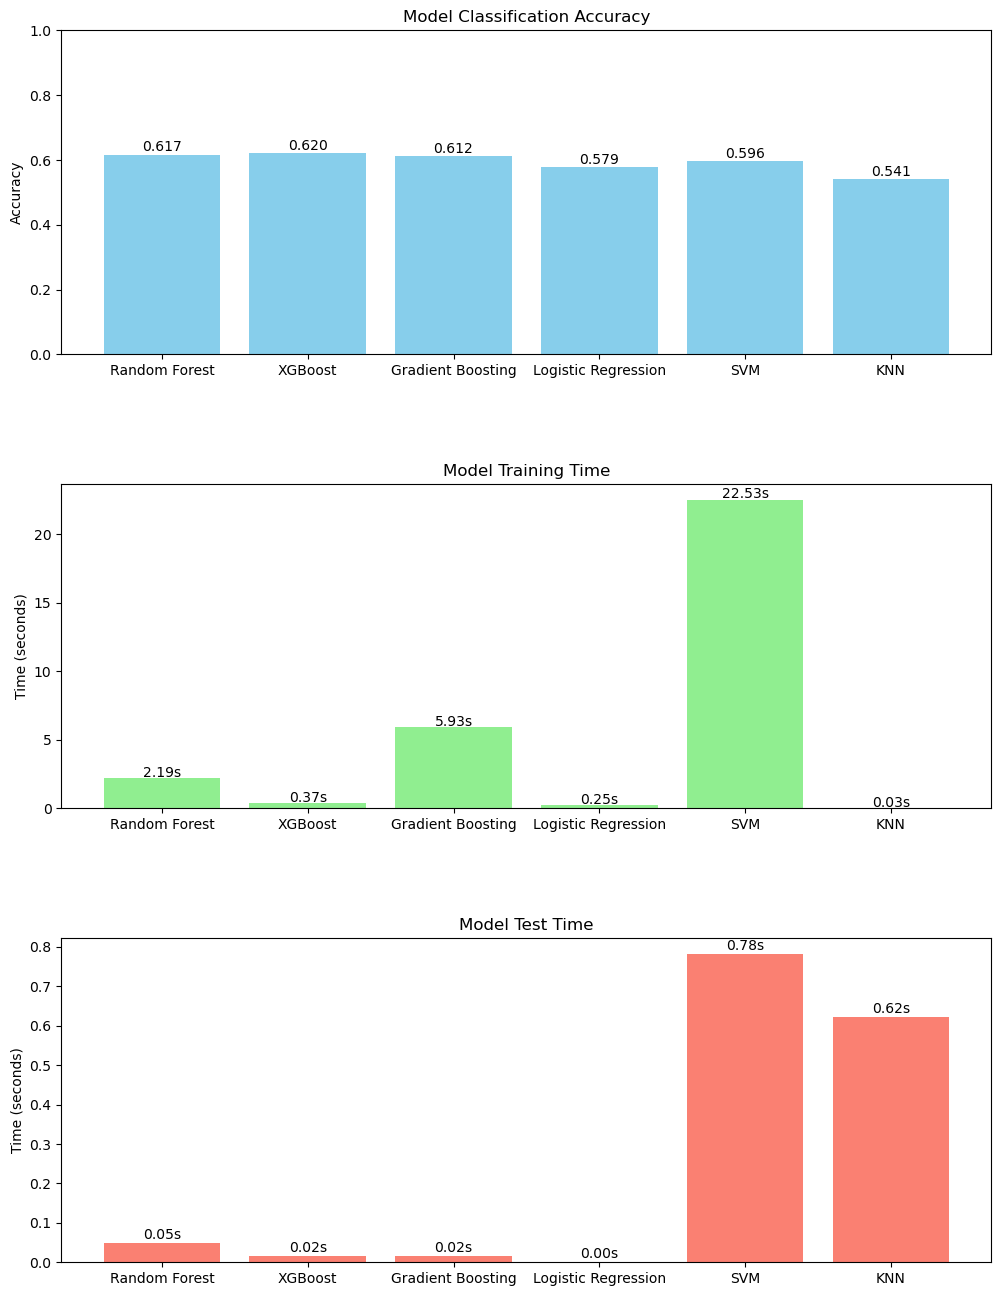

In [13]:
import matplotlib.pyplot as plt

# Prepare plot data: Use best test accuracy, and min training/testing time per model
model_names = list(results.keys())
best_test_accuracies = [max([entry['test_accuracy'] for entry in results[model]]) for model in model_names]
min_training_times = [min([entry['training_time'] for entry in results[model]]) for model in model_names]
min_test_times = [min([entry['test_time'] for entry in results[model]]) for model in model_names]

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 16))
plt.subplots_adjust(hspace=0.4)

# Accuracy plot
axes[0].bar(model_names, best_test_accuracies, color='skyblue')
axes[0].set_title('Model Classification Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(best_test_accuracies):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center')

# Training time plot
axes[1].bar(model_names, min_training_times, color='lightgreen')
axes[1].set_title('Model Training Time')
axes[1].set_ylabel('Time (seconds)')
for i, v in enumerate(min_training_times):
    axes[1].text(i, v + 0.1, f"{v:.2f}s", ha='center')

# Test time plot
axes[2].bar(model_names, min_test_times, color='salmon')
axes[2].set_title('Model Test Time')
axes[2].set_ylabel('Time (seconds)')
for i, v in enumerate(min_test_times):
    axes[2].text(i, v + 0.01, f"{v:.2f}s", ha='center')

plt.show()


In [14]:
# Print best accuracy
if results:
    best_model_entry = max(
        (entry for model_entries in results.values() for entry in model_entries),
        key=lambda x: x['test_accuracy']
    )

    # Search the result was from which model
    for model_name, model_entries in results.items():
        if best_model_entry in model_entries:
            best_model_name = model_name
            break

    best_accuracy = best_model_entry['test_accuracy']
    print("\n" + "="*60)
    print(f"Best Model: {best_model_name} with accuracy: {best_accuracy:.4f}")
    print("="*60)
else:
    print("\nNo models were successfully trained. Please check the feature selection.")

# Save the XGBoost pipeline
import pickle
if 'XGBoost' in results:
    xgb_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            random_state=42,
            eval_metric='mlogloss',
            learning_rate=0.1,

        ))
    ])

    xgb_pipeline.fit(X_train, Y_train)

    with open('xgboost_pipeline.pickle', 'wb') as f:
        pickle.dump(xgb_pipeline, f)

    print("\nXGBoost pipeline saved to 'xgboost_pipeline.pickle'")


Best Model: XGBoost with accuracy: 0.6201

XGBoost pipeline saved to 'xgboost_pipeline.pickle'


In [15]:

summary_table = []

for model_name, entries in results.items():
    best_entry = max(entries, key=lambda x: x['test_accuracy'])
    report = best_entry['classification_report']
    lines = report.split('\n')
    for line in lines:
        if line.strip().startswith('average'):
            avg_metrics = line.strip().split()
            break

    summary_table.append({
        'Model': model_name,
        'Best Params': best_params[model_name],
        'Test Accuracy': best_entry['test_accuracy'],
        'Precision': float(avg_metrics[1]),
        'Recall': float(avg_metrics[2]),
        'F1-Score': float(avg_metrics[3]),
        'Training Time (s)': best_entry['training_time'],
        'Test Time (s)': best_entry['test_time']
    })

# Summary DataFrame
summary_df = pd.DataFrame(summary_table)
summary_df = summary_df.sort_values(by='Test Accuracy', ascending=False)
pd.set_option('display.max_colwidth', None)
display(summary_df)

,Model,Best Params,Test Accuracy,Precision,Recall,F1-Score,Training Time (s),Test Time (s)
1,XGBoost,"{'random_state': 42, 'eval_metric': 'mlogloss', 'learning_rate': 0.1}",0.620057,0.59,0.60,0.60,0.649450,0.046869
0,Random Forest,"{'random_state': 42, 'min_samples_split': 10}",0.616619,0.59,0.53,0.56,4.038384,0.049893
2,Gradient Boosting,"{'random_state': 42, 'max_depth': 5}",0.612034,0.56,0.59,0.58,12.319818,0.097557
4,SVM,"{'random_state': 42, 'probability': True, 'C': 1.0}",0.595989,0.65,0.41,0.51,22.811455,0.899941
3,Logistic Regression,"{'random_state': 42, 'multi_class': 'multinomial', 'max_iter': 200}",0.578797,0.55,0.63,0.59,0.515695,0.000000
5,KNN,{'p': 1},0.540974,0.51,0.57,0.54,0.048786,0.621747
